<a href="https://colab.research.google.com/github/girakageethikasadhan-blip/Credit-Card-Default-Prediction/blob/main/Credit_Card_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [6]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [7]:
scaler = StandardScaler()
df['LIMIT_BAL'] = scaler.fit_transform(df[['LIMIT_BAL']])

In [8]:
df = df[df['LIMIT_BAL'] < df['LIMIT_BAL'].quantile(0.99)]

In [9]:
df = pd.get_dummies(df, columns=['SEX','EDUCATION','MARRIAGE'])

In [10]:
X = df.drop(['ID','default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Accuracy: 0.8091143594153053


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("UCI_Credit_Card.csv")

# Drop ID column
df = df.drop("ID", axis=1)

# Split features and target
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

# Prediction
pred = rf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8153333333333334


In [13]:
model = xgb.XGBClassifier()

model.fit(X_train, y_train)

pred_xgb = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))

XGBoost Accuracy: 0.8073946689595872


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


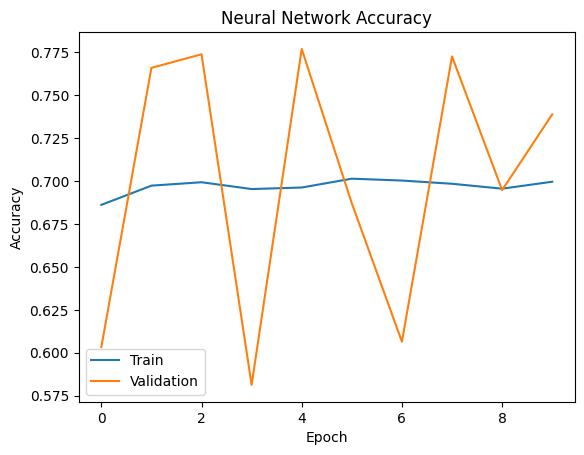

In [18]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Assuming X_train and y_train are already defined and preprocessed from previous steps
# (e.g., cell 2L7Kstn-FhkA or xbc1GrRtJKSz)

# Define a simple Neural Network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 128 units
    Dense(64, activation='relu'), # Hidden layer with 64 units
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model and capture the history
history = model.fit(X_train, y_train,
                    epochs=10, # Number of training epochs, can be adjusted
                    batch_size=32, # Batch size for training
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=0) # Set to 0 to suppress training output

# Plot accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


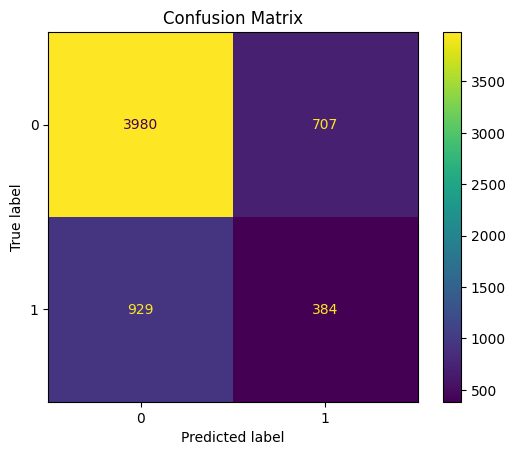

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict values
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot graph
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4516
           1       0.65      0.38      0.48      1299

    accuracy                           0.82      5815
   macro avg       0.74      0.66      0.68      5815
weighted avg       0.80      0.82      0.80      5815



In [20]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# ROC AUC
roc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Precision: 0.3519706691109074
Recall: 0.2924600152322925
ROC-AUC: 0.5708086293357963


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
model.fit(X_train_smote, y_train_smote)

1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5727 - loss: 62.0960


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced")

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor89
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [25]:
df = pd.read_csv("car data.csv")A

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [26]:
df['CarAge'] = 2025 - df['Year']
df.drop(['Year'], axis=1, inplace=True)

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

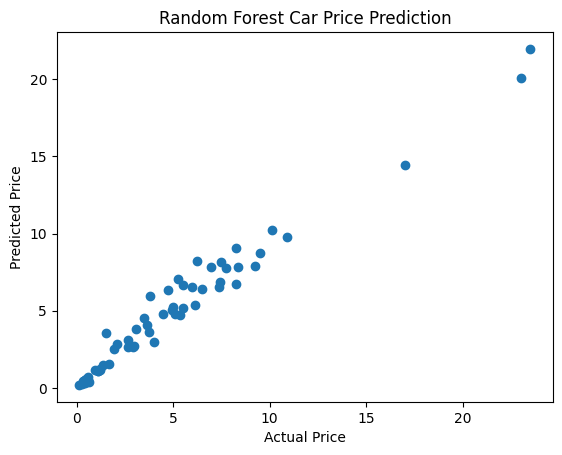

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("car data.csv")

# Feature engineering
df['CarAge'] = 2025 - df['Year']

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Features and target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# Prediction
pred = rf.predict(X_test)

# Graph (Actual vs Predicted)
plt.scatter(y_test, pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Car Price Prediction")

plt.show()

In [31]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_gb))
r2 = r2_score(y_test, pred_gb)

print("Gradient Boosting RMSE:", rmse)
print("Gradient Boosting R2:", r2)

Gradient Boosting RMSE: 0.8700211196636995
Gradient Boosting R2: 0.9671405451858992


In [32]:
model = xgb.XGBRegressor()

model.fit(X_train, y_train)

pred_xgb = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2 = r2_score(y_test, pred_xgb)

print("XGBoost RMSE:", rmse)
print("XGBoost R2:", r2)

XGBoost RMSE: 0.9658764077674172
XGBoost R2: 0.9595010391744149


RMSE: 0.9313702897995577
R2 Score: 0.9623430169111948


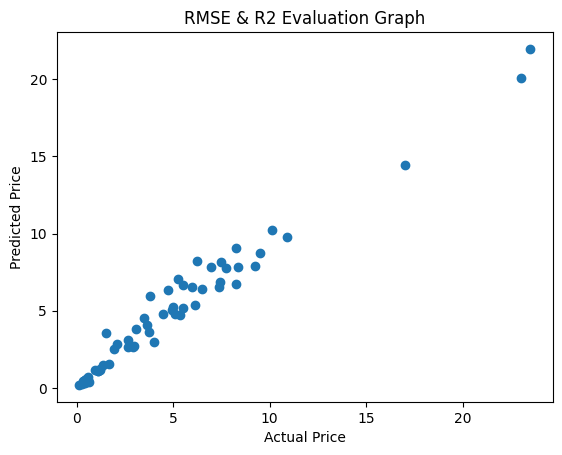

In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# prediction
pred = rf.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

# R2 score
r2 = r2_score(y_test, pred)
print("R2 Score:", r2)

# Graph (Actual vs Predicted)
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("RMSE & R2 Evaluation Graph")

plt.show()